In [1]:
import importlib
import env_utils
import config

importlib.reload(config)
importlib.reload(env_utils)

c:\Users\antho\AppData\Local\Programs\Python\Python312\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


<module 'env_utils' from 'c:\\Users\\antho\\Downloads\\ProjetRL\\env_utils.py'>

In [2]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
from env_utils import make_env

env = make_env(render_mode="rgb_array")

print("duration =", env.unwrapped.config["duration"])
print("policy_frequency =", env.unwrapped.config["policy_frequency"])

duration = 500
policy_frequency = 1


DQN

In [ ]:
agent, logs = train_dqn(
    env=env,
    device=device,
    num_episodes=500,
    batch_size=64,
    buffer_capacity=100000,
    min_buffer_size=1000,
    gamma=0.99,
    lr=1e-3,
    hidden_dim=256,
    target_update_freq=500,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay_steps=10000,
    max_steps_per_episode=200,
    model_save_path="results/dqn_model.pt",
)

Episode 1/500 | Reward: 43.33 | Avg100: 43.33 | Epsilon: 0.995 | Len: 57 | Loss: N/A
Episode 2/500 | Reward: 17.89 | Avg100: 30.61 | Epsilon: 0.993 | Len: 22 | Loss: N/A
Episode 3/500 | Reward: 14.49 | Avg100: 25.24 | Epsilon: 0.991 | Len: 18 | Loss: N/A
Episode 4/500 | Reward: 32.11 | Avg100: 26.96 | Epsilon: 0.987 | Len: 37 | Loss: N/A
Episode 5/500 | Reward: 27.51 | Avg100: 27.07 | Epsilon: 0.984 | Len: 32 | Loss: N/A
Episode 6/500 | Reward: 20.01 | Avg100: 25.89 | Epsilon: 0.982 | Len: 25 | Loss: N/A
Episode 7/500 | Reward: 19.94 | Avg100: 25.04 | Epsilon: 0.980 | Len: 24 | Loss: N/A
Episode 8/500 | Reward: 9.83 | Avg100: 23.14 | Epsilon: 0.978 | Len: 13 | Loss: N/A
Episode 9/500 | Reward: 13.29 | Avg100: 22.04 | Epsilon: 0.977 | Len: 16 | Loss: N/A
Episode 10/500 | Reward: 26.03 | Avg100: 22.44 | Epsilon: 0.974 | Len: 34 | Loss: N/A
Episode 11/500 | Reward: 25.61 | Avg100: 22.73 | Epsilon: 0.971 | Len: 33 | Loss: N/A
Episode 12/500 | Reward: 77.49 | Avg100: 27.29 | Epsilon: 0.962 

GRAPHS

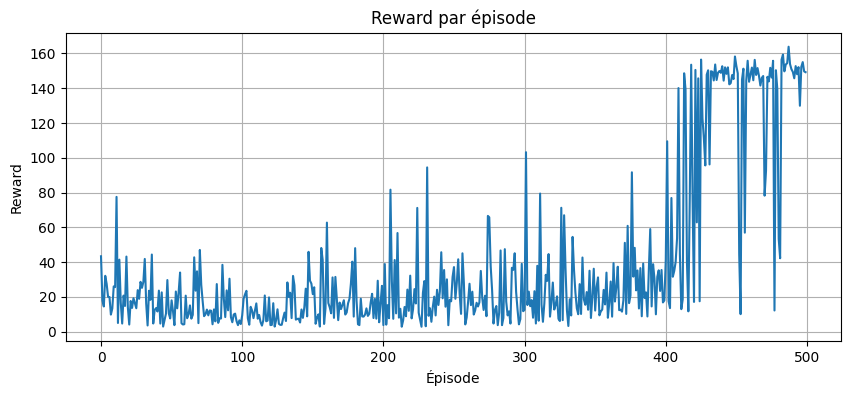

In [54]:
plt.figure(figsize=(10, 4))
plt.plot(logs["episode_rewards"])
plt.title("Reward par épisode")
plt.xlabel("Épisode")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

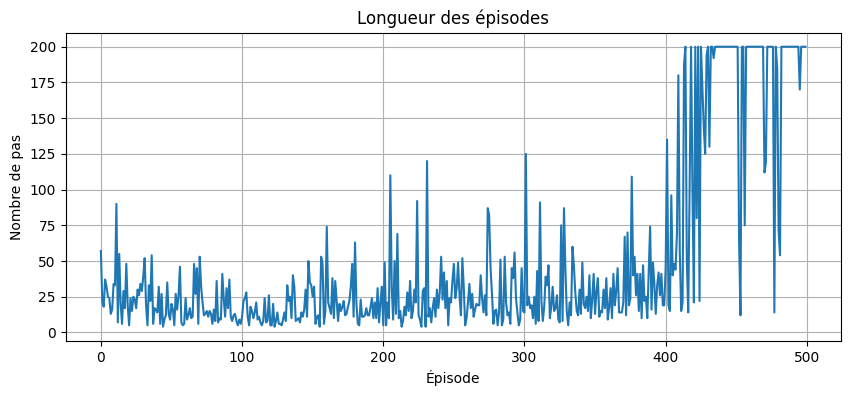

In [55]:
plt.figure(figsize=(10, 4))
plt.plot(logs["episode_lengths"])
plt.title("Longueur des épisodes")
plt.xlabel("Épisode")
plt.ylabel("Nombre de pas")
plt.grid(True)
plt.show()

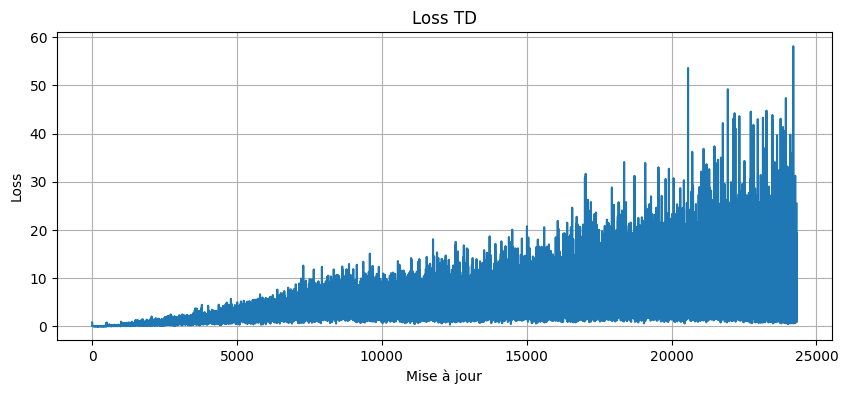

In [56]:
plt.figure(figsize=(10, 4))
plt.plot(logs["losses"])
plt.title("Loss TD")
plt.xlabel("Mise à jour")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

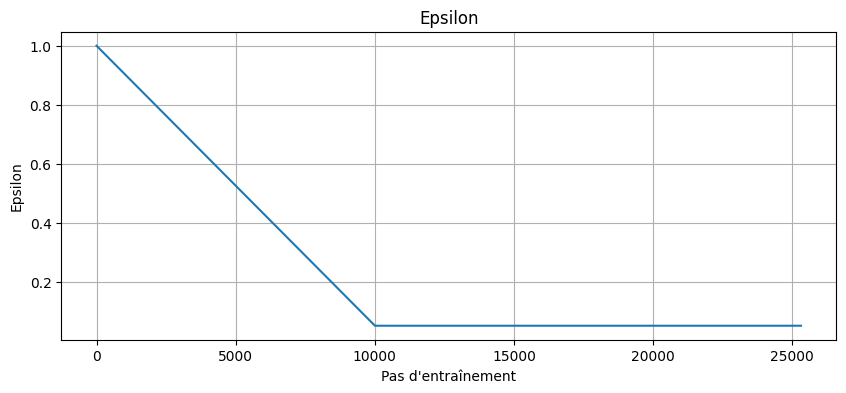

In [57]:
plt.figure(figsize=(10, 4))
plt.plot(logs["epsilons"])
plt.title("Epsilon")
plt.xlabel("Pas d'entraînement")
plt.ylabel("Epsilon")
plt.grid(True)
plt.show()

EVAL

In [58]:
eval_env = make_env(render_mode="rgb_array")
state, info = eval_env.reset()

frames = []
rewards = []
actions = []

done = False
truncated = False

while not (done or truncated):
    frame = eval_env.render()
    if frame is not None:
        frames.append(frame)

    action = agent.act(state, epsilon=0.0)
    actions.append(action)

    state, reward, done, truncated, info = eval_env.step(action)
    rewards.append(reward)

print("Reward total évaluation :", sum(rewards))
print("Nombre d'actions :", len(actions))

Reward total évaluation : 372.9136528142717
Nombre d'actions : 500


In [ ]:
import importlib
import video_utils

importlib.reload(video_utils)

from video_utils import show_video

show_video(frames)

: 

In [47]:
env = make_env(render_mode="rgb_array")

print("duration =", env.unwrapped.config.get("duration"))
print("policy_frequency =", env.unwrapped.config.get("policy_frequency"))
print("simulation_frequency =", env.unwrapped.config.get("simulation_frequency"))
print("action space =", env.action_space)
print("observation shape =", env.observation_space.shape)

duration = 40
policy_frequency = 1
simulation_frequency = 15
action space = Discrete(5)
observation shape = (15, 5)


DQN V2 - PENALITE CHANGEMENT DE VOIE / ACCELERATION

In [5]:
import importlib
import config
import custom_highway_env
import env_utils

importlib.reload(config)
importlib.reload(custom_highway_env)
importlib.reload(env_utils)

<module 'env_utils' from 'c:\\Users\\antho\\Downloads\\ProjetRL\\env_utils.py'>

In [6]:
from env_utils import make_env, print_env_info

env = make_env(render_mode=None)
print_env_info(env)

Observation space: Box(-inf, inf, (15, 5), float32)
Action space: Discrete(5)
Observation shape: (15, 5)
Sample observation:
[[ 1.          1.          0.12        1.          0.        ]
 [ 1.          0.2304852  -0.12       -0.08770879  0.        ]
 [ 1.          0.4323653   0.         -0.12217125  0.        ]
 [ 1.          0.6225341  -0.08       -0.14395134  0.        ]
 [ 1.          0.8453682  -0.04       -0.16063093  0.        ]
 [ 1.          1.         -0.12       -0.0753331   0.        ]
 [ 1.          1.         -0.12       -0.11009258  0.        ]
 [ 1.          1.         -0.08       -0.08338927  0.        ]
 [ 1.          1.         -0.08       -0.17841537  0.        ]
 [ 1.          1.         -0.08       -0.0983512   0.        ]
 [ 0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.   

In [ ]:
from train import train_dqn
agent, logs = train_dqn(
    env=env,
    device=device,
    num_episodes=1000,
    batch_size=64,
    buffer_capacity=100000,
    min_buffer_size=2000,
    gamma=0.99,
    lr=1e-3,
    hidden_dim=256,
    target_update_freq=500,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay_steps=50000,
    max_steps_per_episode=250,
    model_save_path="results/dqn_modelv2.pt",
)

Episode 1/1000 | Reward: -7.86 | Avg100: -7.86 | Epsilon: 1.000 | Len: 22 | Loss: N/A
Episode 2/1000 | Reward: -3.86 | Avg100: -5.86 | Epsilon: 0.999 | Len: 36 | Loss: N/A
Episode 3/1000 | Reward: -0.06 | Avg100: -3.93 | Epsilon: 0.998 | Len: 25 | Loss: N/A
Episode 4/1000 | Reward: -10.31 | Avg100: -5.53 | Epsilon: 0.998 | Len: 5 | Loss: N/A
Episode 5/1000 | Reward: -10.85 | Avg100: -6.59 | Epsilon: 0.998 | Len: 6 | Loss: N/A
Episode 6/1000 | Reward: -10.15 | Avg100: -7.18 | Epsilon: 0.998 | Len: 5 | Loss: N/A
Episode 7/1000 | Reward: -10.06 | Avg100: -7.59 | Epsilon: 0.998 | Len: 3 | Loss: N/A
Episode 8/1000 | Reward: -7.31 | Avg100: -7.56 | Epsilon: 0.998 | Len: 25 | Loss: N/A
Episode 9/1000 | Reward: -9.68 | Avg100: -7.79 | Epsilon: 0.998 | Len: 3 | Loss: N/A
Episode 10/1000 | Reward: -9.18 | Avg100: -7.93 | Epsilon: 0.997 | Len: 10 | Loss: N/A
Episode 11/1000 | Reward: -7.41 | Avg100: -7.89 | Epsilon: 0.997 | Len: 8 | Loss: N/A
Episode 12/1000 | Reward: -8.56 | Avg100: -7.94 | Epsi

In [10]:
eval_env = make_env(render_mode="rgb_array")
state, info = eval_env.reset()

frames = []
rewards = []
actions = []

done = False
truncated = False

while not (done or truncated):
    frame = eval_env.render()
    if frame is not None:
        frames.append(frame)

    action = agent.act(state, epsilon=0.0)
    actions.append(action)

    state, reward, done, truncated, info = eval_env.step(action)
    rewards.append(reward)

print("Reward totale :", sum(rewards))
print("Nombre d'actions :", len(actions))

Reward totale : -4.30896231352645
Nombre d'actions : 250


In [11]:
import importlib
import video_utils

importlib.reload(video_utils)

from video_utils import show_video

show_video(frames)

DQN V3 PENALISATION DES ACCELERATIONS LONGITUDINALES

In [12]:
import importlib
import config
import custom_highway_env
import env_utils

importlib.reload(config)
importlib.reload(custom_highway_env)
importlib.reload(env_utils)

<module 'env_utils' from 'c:\\Users\\antho\\Downloads\\ProjetRL\\env_utils.py'>

In [13]:
from env_utils import make_env, print_env_info

env = make_env(render_mode=None)
print_env_info(env)

Observation space: Box(-inf, inf, (15, 5), float32)
Action space: Discrete(5)
Observation shape: (15, 5)
Sample observation:
[[ 1.          1.          0.12        1.          0.        ]
 [ 1.          0.2304852  -0.12       -0.08770879  0.        ]
 [ 1.          0.4323653   0.         -0.12217125  0.        ]
 [ 1.          0.6225341  -0.08       -0.14395134  0.        ]
 [ 1.          0.8453682  -0.04       -0.16063093  0.        ]
 [ 1.          1.         -0.12       -0.0753331   0.        ]
 [ 1.          1.         -0.12       -0.11009258  0.        ]
 [ 1.          1.         -0.08       -0.08338927  0.        ]
 [ 1.          1.         -0.08       -0.17841537  0.        ]
 [ 1.          1.         -0.08       -0.0983512   0.        ]
 [ 0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.   

In [14]:
from train import train_dqn
agent, logs = train_dqn(
    env=env,
    device=device,
    num_episodes=1000,
    batch_size=64,
    buffer_capacity=100000,
    min_buffer_size=2000,
    gamma=0.99,
    lr=1e-3,
    hidden_dim=256,
    target_update_freq=500,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay_steps=20000,
    max_steps_per_episode=500,
    model_save_path="results/dqn_modelv3.pt",
)

Episode 1/1000 | Reward: -14.53 | Avg100: -14.53 | Epsilon: 0.999 | Len: 26 | Loss: N/A
Episode 2/1000 | Reward: -7.90 | Avg100: -11.21 | Epsilon: 0.998 | Len: 23 | Loss: N/A
Episode 3/1000 | Reward: -12.24 | Avg100: -11.55 | Epsilon: 0.997 | Len: 22 | Loss: N/A
Episode 4/1000 | Reward: -7.78 | Avg100: -10.61 | Epsilon: 0.996 | Len: 11 | Loss: N/A
Episode 5/1000 | Reward: -10.35 | Avg100: -10.56 | Epsilon: 0.996 | Len: 6 | Loss: N/A
Episode 6/1000 | Reward: -9.61 | Avg100: -10.40 | Epsilon: 0.996 | Len: 4 | Loss: N/A
Episode 7/1000 | Reward: -12.27 | Avg100: -10.67 | Epsilon: 0.995 | Len: 14 | Loss: N/A
Episode 8/1000 | Reward: -12.63 | Avg100: -10.91 | Epsilon: 0.994 | Len: 25 | Loss: N/A
Episode 9/1000 | Reward: -9.14 | Avg100: -10.72 | Epsilon: 0.993 | Len: 11 | Loss: N/A
Episode 10/1000 | Reward: -9.71 | Avg100: -10.62 | Epsilon: 0.993 | Len: 3 | Loss: N/A
Episode 11/1000 | Reward: -10.62 | Avg100: -10.62 | Epsilon: 0.993 | Len: 5 | Loss: N/A
Episode 12/1000 | Reward: -10.34 | Avg1

In [15]:
eval_env = make_env(render_mode="rgb_array")
state, info = eval_env.reset()

frames = []
rewards = []
actions = []

done = False
truncated = False

while not (done or truncated):
    frame = eval_env.render()
    if frame is not None:
        frames.append(frame)

    action = agent.act(state, epsilon=0.0)
    actions.append(action)

    state, reward, done, truncated, info = eval_env.step(action)
    rewards.append(reward)

print("Reward totale :", sum(rewards))
print("Nombre d'actions :", len(actions))

Reward totale : -19.038229270256146
Nombre d'actions : 254


In [16]:
import importlib
import video_utils

importlib.reload(video_utils)

from video_utils import show_video

show_video(frames)

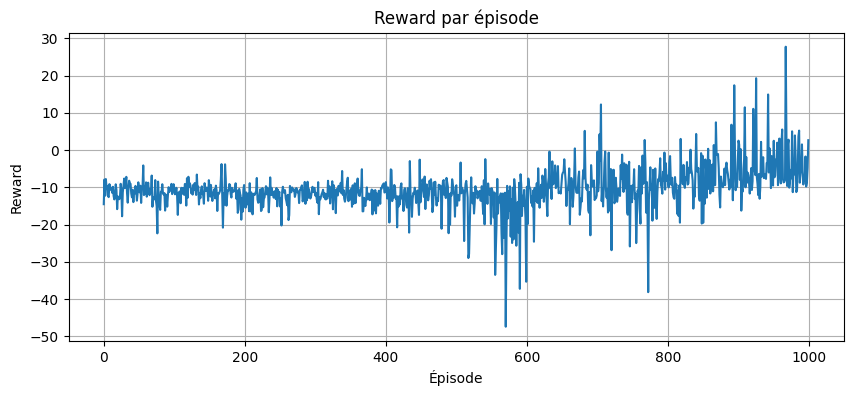

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(logs["episode_rewards"])
plt.title("Reward par épisode")
plt.xlabel("Épisode")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

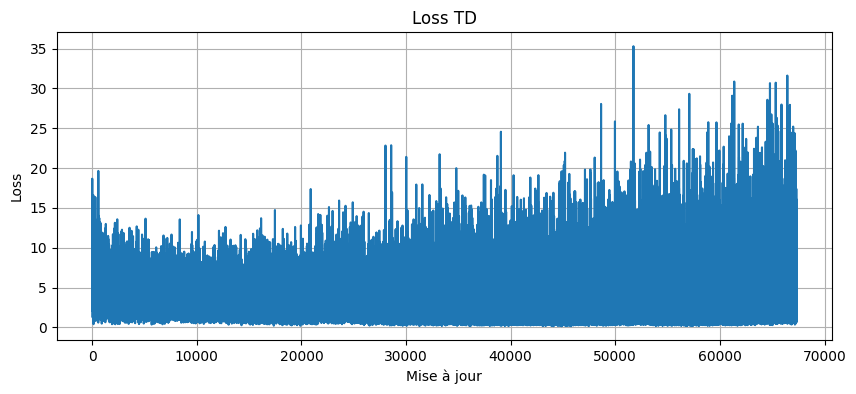

In [18]:
plt.figure(figsize=(10, 4))
plt.plot(logs["losses"])
plt.title("Loss TD")
plt.xlabel("Mise à jour")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

DQN V4

In [6]:
from train import train_dqn
agent, logs = train_dqn(
    env=env,
    device=device,
    num_episodes=1000,
    batch_size=64,
    buffer_capacity=100000,
    min_buffer_size=2000,
    gamma=0.99,
    lr=5e-4,
    hidden_dim=256,
    target_update_freq=1000,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay_steps=100000,
    max_steps_per_episode=500,
    model_save_path="results/dqn_model_family.pt",
)

Episode 1/1000 | Reward: -8.66 | Avg100: -8.66 | Epsilon: 1.000 | Len: 5 | Loss: N/A
Episode 2/1000 | Reward: -7.86 | Avg100: -8.26 | Epsilon: 1.000 | Len: 10 | Loss: N/A
Episode 3/1000 | Reward: -10.07 | Avg100: -8.86 | Epsilon: 1.000 | Len: 3 | Loss: N/A
Episode 4/1000 | Reward: -16.30 | Avg100: -10.72 | Epsilon: 0.999 | Len: 39 | Loss: N/A
Episode 5/1000 | Reward: -10.76 | Avg100: -10.73 | Epsilon: 0.999 | Len: 3 | Loss: N/A
Episode 6/1000 | Reward: -12.26 | Avg100: -10.98 | Epsilon: 0.999 | Len: 34 | Loss: N/A
Episode 7/1000 | Reward: -11.75 | Avg100: -11.09 | Epsilon: 0.999 | Len: 3 | Loss: N/A
Episode 8/1000 | Reward: -8.78 | Avg100: -10.80 | Epsilon: 0.999 | Len: 9 | Loss: N/A
Episode 9/1000 | Reward: -9.06 | Avg100: -10.61 | Epsilon: 0.999 | Len: 32 | Loss: N/A
Episode 10/1000 | Reward: -14.94 | Avg100: -11.04 | Epsilon: 0.999 | Len: 16 | Loss: N/A
Episode 11/1000 | Reward: -11.86 | Avg100: -11.12 | Epsilon: 0.999 | Len: 4 | Loss: N/A
Episode 12/1000 | Reward: -19.37 | Avg100: 

In [8]:
eval_env = make_env(render_mode="rgb_array")
state, info = eval_env.reset()

frames = []
rewards = []
actions = []

done = False
truncated = False

while not (done or truncated):
    frame = eval_env.render()
    if frame is not None:
        frames.append(frame)

    action = agent.act(state, epsilon=0.0)
    actions.append(action)

    state, reward, done, truncated, info = eval_env.step(action)
    rewards.append(reward)

print("Reward totale :", sum(rewards))
print("Nombre d'actions :", len(actions))

Reward totale : 12.683046337373893
Nombre d'actions : 500


In [9]:
import importlib
import video_utils

importlib.reload(video_utils)

from video_utils import show_video

show_video(frames)

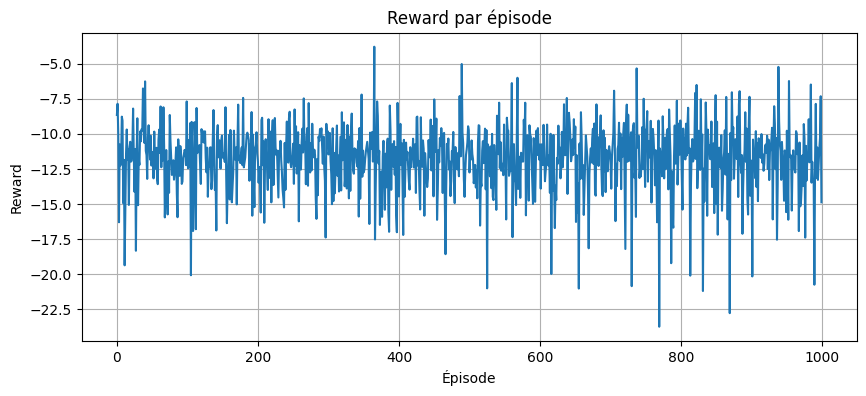

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(logs["episode_rewards"])
plt.title("Reward par épisode")
plt.xlabel("Épisode")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

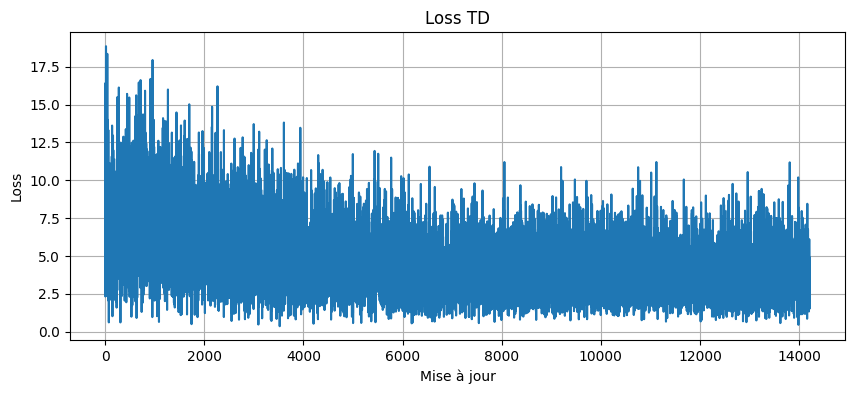

In [11]:
plt.figure(figsize=(10, 4))
plt.plot(logs["losses"])
plt.title("Loss TD")
plt.xlabel("Mise à jour")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

DQN V5 vitesse cible

In [13]:
from train import train_dqn
agent, logs = train_dqn(
    env=env,
    device=device,
    num_episodes=1000,
    batch_size=64,
    buffer_capacity=100000,
    min_buffer_size=2000,
    gamma=0.99,
    lr=5e-4,
    hidden_dim=256,
    target_update_freq=1000,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay_steps=20000,
    max_steps_per_episode=500,
    model_save_path="results/dqn_model_family_vitesse_cible.pt",
)

Episode 1/1000 | Reward: -11.65 | Avg100: -11.65 | Epsilon: 1.000 | Len: 5 | Loss: N/A
Episode 2/1000 | Reward: -6.10 | Avg100: -8.87 | Epsilon: 0.999 | Len: 10 | Loss: N/A
Episode 3/1000 | Reward: -12.11 | Avg100: -9.95 | Epsilon: 0.999 | Len: 3 | Loss: N/A
Episode 4/1000 | Reward: -10.53 | Avg100: -10.10 | Epsilon: 0.998 | Len: 24 | Loss: N/A
Episode 5/1000 | Reward: -11.30 | Avg100: -10.34 | Epsilon: 0.998 | Len: 3 | Loss: N/A
Episode 6/1000 | Reward: -13.56 | Avg100: -10.87 | Epsilon: 0.997 | Len: 9 | Loss: N/A
Episode 7/1000 | Reward: -11.01 | Avg100: -10.89 | Epsilon: 0.997 | Len: 4 | Loss: N/A
Episode 8/1000 | Reward: -13.11 | Avg100: -11.17 | Epsilon: 0.996 | Len: 29 | Loss: N/A
Episode 9/1000 | Reward: -12.22 | Avg100: -11.29 | Epsilon: 0.996 | Len: 6 | Loss: N/A
Episode 10/1000 | Reward: -8.97 | Avg100: -11.06 | Epsilon: 0.995 | Len: 5 | Loss: N/A
Episode 11/1000 | Reward: -14.28 | Avg100: -11.35 | Epsilon: 0.994 | Len: 21 | Loss: N/A
Episode 12/1000 | Reward: -12.33 | Avg100

In [14]:
eval_env = make_env(render_mode="rgb_array")
state, info = eval_env.reset()

frames = []
rewards = []
actions = []

done = False
truncated = False

while not (done or truncated):
    frame = eval_env.render()
    if frame is not None:
        frames.append(frame)

    action = agent.act(state, epsilon=0.0)
    actions.append(action)

    state, reward, done, truncated, info = eval_env.step(action)
    rewards.append(reward)

print("Reward totale :", sum(rewards))
print("Nombre d'actions :", len(actions))

Reward totale : -19.82617416094356
Nombre d'actions : 290


In [15]:
import importlib
import video_utils

importlib.reload(video_utils)

from video_utils import show_video

show_video(frames)

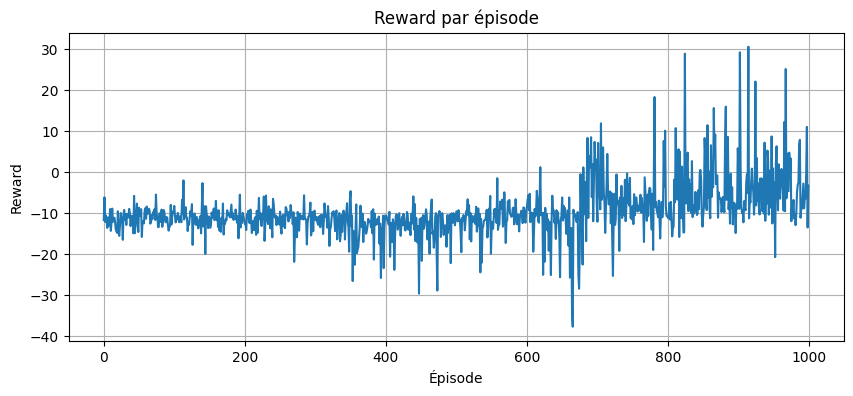

In [16]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(logs["episode_rewards"])
plt.title("Reward par épisode")
plt.xlabel("Épisode")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

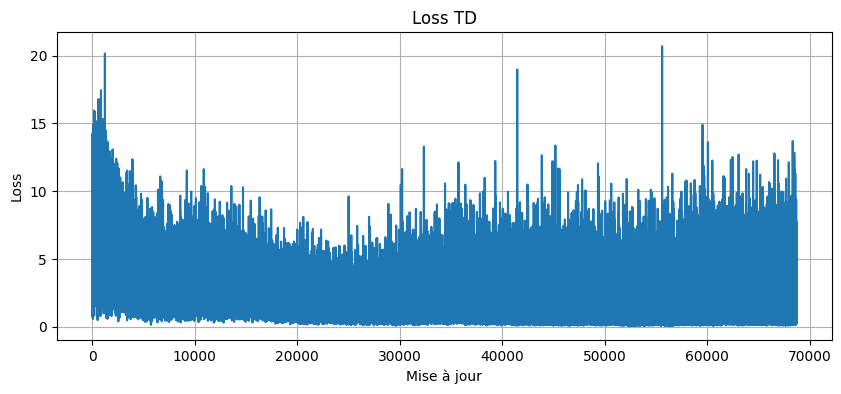

In [17]:
plt.figure(figsize=(10, 4))
plt.plot(logs["losses"])
plt.title("Loss TD")
plt.xlabel("Mise à jour")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

DQN V6 - Vitesse cible dynamique, dépassement fluide

In [9]:
from train import train_dqn
agent, logs = train_dqn(
    env=env,
    device=device,
    num_episodes=1000,
    batch_size=64,
    buffer_capacity=100000,
    min_buffer_size=2000,
    gamma=0.99,
    lr=5e-4,
    hidden_dim=256,
    target_update_freq=1000,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay_steps=30000,
    max_steps_per_episode=500,
    model_save_path="results/dqnV6_model_smooth_fast.pt",
)

[DQN] Episode 1/1000 | Reward: -8.12 | Avg100: -8.12 | Epsilon: 1.000 | Len: 12 | Loss: N/A
[DQN] Episode 2/1000 | Reward: -13.92 | Avg100: -11.02 | Epsilon: 0.999 | Len: 9 | Loss: N/A
[DQN] Episode 3/1000 | Reward: -17.90 | Avg100: -13.32 | Epsilon: 0.999 | Len: 11 | Loss: N/A
[DQN] Episode 4/1000 | Reward: -16.17 | Avg100: -14.03 | Epsilon: 0.999 | Len: 15 | Loss: N/A
[DQN] Episode 5/1000 | Reward: -15.81 | Avg100: -14.39 | Epsilon: 0.998 | Len: 14 | Loss: N/A
[DQN] Episode 6/1000 | Reward: -19.42 | Avg100: -15.23 | Epsilon: 0.998 | Len: 14 | Loss: N/A
[DQN] Episode 7/1000 | Reward: -12.99 | Avg100: -14.91 | Epsilon: 0.998 | Len: 2 | Loss: N/A
[DQN] Episode 8/1000 | Reward: -20.60 | Avg100: -15.62 | Epsilon: 0.997 | Len: 13 | Loss: N/A
[DQN] Episode 9/1000 | Reward: -19.37 | Avg100: -16.04 | Epsilon: 0.997 | Len: 19 | Loss: N/A
[DQN] Episode 10/1000 | Reward: -27.57 | Avg100: -17.19 | Epsilon: 0.996 | Len: 19 | Loss: N/A
[DQN] Episode 11/1000 | Reward: -13.62 | Avg100: -16.86 | Epsil

In [10]:
eval_env = make_env(render_mode="rgb_array")
state, info = eval_env.reset()

frames = []
rewards = []
actions = []

done = False
truncated = False

while not (done or truncated):
    frame = eval_env.render()
    if frame is not None:
        frames.append(frame)

    action = agent.act(state, epsilon=0.0)
    actions.append(action)

    state, reward, done, truncated, info = eval_env.step(action)
    rewards.append(reward)

print("Reward totale :", sum(rewards))
print("Nombre d'actions :", len(actions))

Reward totale : 83.23957545288303
Nombre d'actions : 500


In [11]:
import importlib
import video_utils

importlib.reload(video_utils)

from video_utils import show_video

show_video(frames)

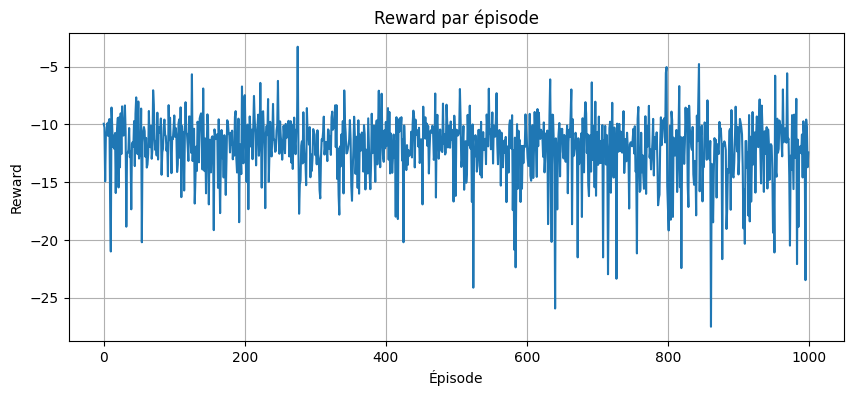

In [21]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(logs["episode_rewards"])
plt.title("Reward par épisode")
plt.xlabel("Épisode")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(logs["losses"])
plt.title("Loss TD")
plt.xlabel("Mise à jour")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

DOUBLE DQN V1

In [4]:
import importlib
import agents
import train

importlib.reload(agents)
importlib.reload(train)

<module 'train' from 'c:\\Users\\antho\\Downloads\\ProjetRL\\train.py'>

In [5]:
from train import train_dqn
agent_double, logs_double = train_dqn(
    env=env,
    device=device,
    agent_type="double_dqn",
    num_episodes=1000,
    batch_size=64,
    buffer_capacity=100000,
    min_buffer_size=2000,
    gamma=0.99,
    lr=5e-4,
    hidden_dim=256,
    target_update_freq=1000,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay_steps=25000,
    max_steps_per_episode=500,
    model_save_path="results/double_dqn_modelV1.pt",
)

[DOUBLE_DQN] Episode 1/1000 | Reward: -19.26 | Avg100: -19.26 | Epsilon: 0.999 | Len: 26 | Loss: N/A
[DOUBLE_DQN] Episode 2/1000 | Reward: -25.64 | Avg100: -22.45 | Epsilon: 0.998 | Len: 32 | Loss: N/A
[DOUBLE_DQN] Episode 3/1000 | Reward: -24.84 | Avg100: -23.24 | Epsilon: 0.997 | Len: 15 | Loss: N/A
[DOUBLE_DQN] Episode 4/1000 | Reward: -18.10 | Avg100: -21.96 | Epsilon: 0.997 | Len: 4 | Loss: N/A
[DOUBLE_DQN] Episode 5/1000 | Reward: -20.14 | Avg100: -21.59 | Epsilon: 0.996 | Len: 26 | Loss: N/A
[DOUBLE_DQN] Episode 6/1000 | Reward: -17.32 | Avg100: -20.88 | Epsilon: 0.996 | Len: 3 | Loss: N/A
[DOUBLE_DQN] Episode 7/1000 | Reward: -10.70 | Avg100: -19.43 | Epsilon: 0.996 | Len: 4 | Loss: N/A
[DOUBLE_DQN] Episode 8/1000 | Reward: -15.87 | Avg100: -18.98 | Epsilon: 0.996 | Len: 8 | Loss: N/A
[DOUBLE_DQN] Episode 9/1000 | Reward: -17.30 | Avg100: -18.79 | Epsilon: 0.995 | Len: 17 | Loss: N/A
[DOUBLE_DQN] Episode 10/1000 | Reward: -20.15 | Avg100: -18.93 | Epsilon: 0.994 | Len: 29 | Los

In [7]:
eval_env = make_env(render_mode="rgb_array")
state, info = eval_env.reset()

frames = []
rewards = []
actions = []

done = False
truncated = False

while not (done or truncated):
    frame = eval_env.render()
    if frame is not None:
        frames.append(frame)

    action = agent_double.act(state, epsilon=0.0)
    actions.append(action)

    state, reward, done, truncated, info = eval_env.step(action)
    rewards.append(reward)

print("Reward totale :", sum(rewards))
print("Nombre d'actions :", len(actions))

Reward totale : 96.5416203754792
Nombre d'actions : 500


In [8]:
import importlib
import video_utils

importlib.reload(video_utils)

from video_utils import show_video

show_video(frames)

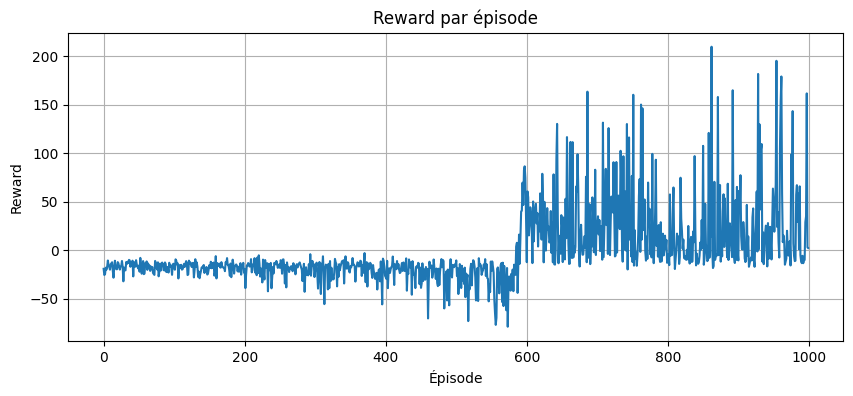

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(logs_double["episode_rewards"])
plt.title("Reward par épisode")
plt.xlabel("Épisode")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

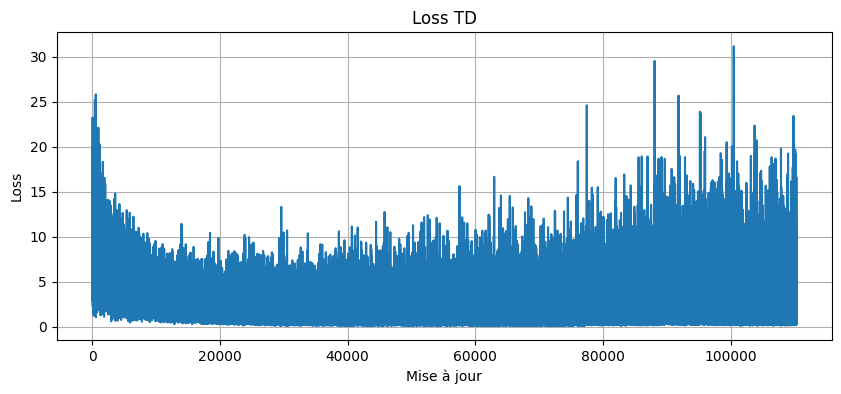

In [10]:
plt.figure(figsize=(10, 4))
plt.plot(logs_double["losses"])
plt.title("Loss TD")
plt.xlabel("Mise à jour")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

DUELING DQN

In [11]:
import importlib
import models
import agents
import train

importlib.reload(models)
importlib.reload(agents)
importlib.reload(train)

<module 'train' from 'c:\\Users\\antho\\Downloads\\ProjetRL\\train.py'>

In [15]:
from train import train_dqn

agent_dueling, logs_dueling = train_dqn(
    env=env,
    device=device,
    agent_type="dueling_dqn",
    num_episodes=1000,
    batch_size=64,
    buffer_capacity=100000,
    min_buffer_size=2000,
    gamma=0.99,
    lr=5e-4,
    hidden_dim=256,
    target_update_freq=1000,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay_steps=30000,
    max_steps_per_episode=500,
    model_save_path="results/dueling_dqn_model.pt",
)

[DUELING_DQN] Episode 1/1000 | Reward: -22.63 | Avg100: -22.63 | Epsilon: 0.999 | Len: 18 | Loss: N/A
[DUELING_DQN] Episode 2/1000 | Reward: -16.05 | Avg100: -19.34 | Epsilon: 0.999 | Len: 10 | Loss: N/A
[DUELING_DQN] Episode 3/1000 | Reward: -14.57 | Avg100: -17.75 | Epsilon: 0.999 | Len: 10 | Loss: N/A
[DUELING_DQN] Episode 4/1000 | Reward: -15.49 | Avg100: -17.18 | Epsilon: 0.999 | Len: 8 | Loss: N/A
[DUELING_DQN] Episode 5/1000 | Reward: -32.66 | Avg100: -20.28 | Epsilon: 0.998 | Len: 27 | Loss: N/A
[DUELING_DQN] Episode 6/1000 | Reward: -14.95 | Avg100: -19.39 | Epsilon: 0.997 | Len: 8 | Loss: N/A
[DUELING_DQN] Episode 7/1000 | Reward: -15.95 | Avg100: -18.90 | Epsilon: 0.997 | Len: 16 | Loss: N/A
[DUELING_DQN] Episode 8/1000 | Reward: -14.13 | Avg100: -18.30 | Epsilon: 0.997 | Len: 7 | Loss: N/A
[DUELING_DQN] Episode 9/1000 | Reward: -37.84 | Avg100: -20.48 | Epsilon: 0.996 | Len: 29 | Loss: N/A
[DUELING_DQN] Episode 10/1000 | Reward: -14.64 | Avg100: -19.89 | Epsilon: 0.996 | Le

In [16]:
eval_env = make_env(render_mode="rgb_array")
state, info = eval_env.reset()

frames = []
rewards = []
actions = []

done = False
truncated = False

while not (done or truncated):
    frame = eval_env.render()
    if frame is not None:
        frames.append(frame)

    action = agent_dueling.act(state, epsilon=0.0)
    actions.append(action)

    state, reward, done, truncated, info = eval_env.step(action)
    rewards.append(reward)

print("Reward totale :", sum(rewards))
print("Nombre d'actions :", len(actions))

Reward totale : 13.300608716150894
Nombre d'actions : 308


In [17]:
import importlib
import video_utils

importlib.reload(video_utils)

from video_utils import show_video

show_video(frames)

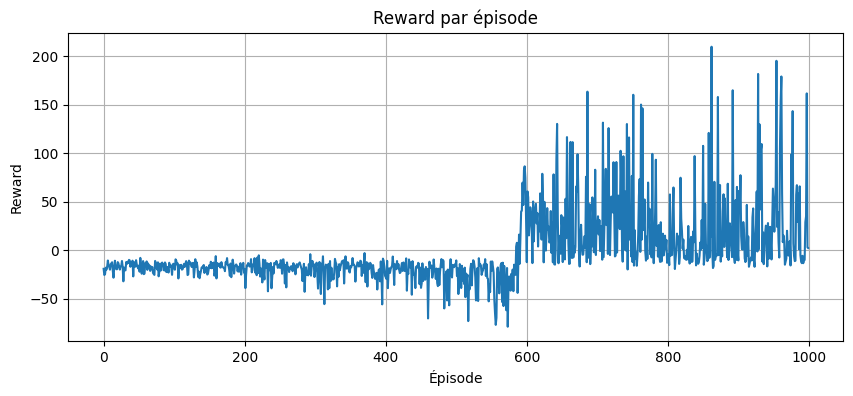

In [18]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(logs_double["episode_rewards"])
plt.title("Reward par épisode")
plt.xlabel("Épisode")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

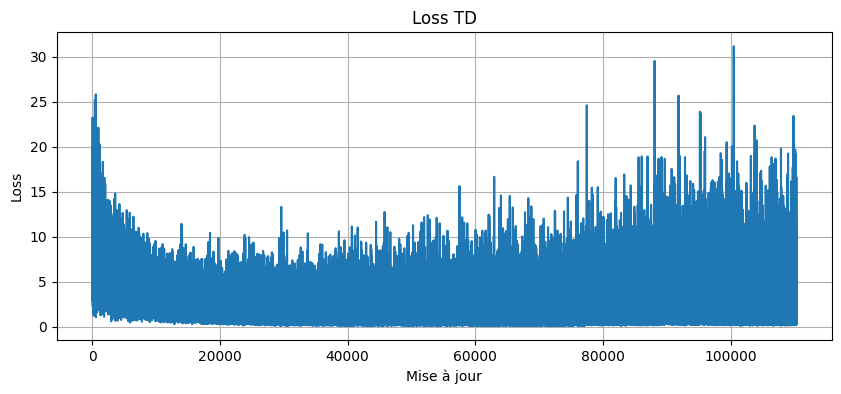

In [19]:
plt.figure(figsize=(10, 4))
plt.plot(logs_double["losses"])
plt.title("Loss TD")
plt.xlabel("Mise à jour")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

DUELING DOUBLE

In [20]:
import importlib
import models
import agents
import train

importlib.reload(models)
importlib.reload(agents)
importlib.reload(train)

<module 'train' from 'c:\\Users\\antho\\Downloads\\ProjetRL\\train.py'>

In [21]:
from train import train_dqn

agent_dueling_double, logs_dueling_double = train_dqn(
    env=env,
    device=device,
    agent_type="dueling_double_dqn",
    num_episodes=1000,
    batch_size=64,
    buffer_capacity=100000,
    min_buffer_size=2000,
    gamma=0.99,
    lr=5e-4,
    hidden_dim=256,
    target_update_freq=1000,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay_steps=30000,
    max_steps_per_episode=500,
    model_save_path="results/dueling_double_dqn_model.pt",
)

[DUELING_DOUBLE_DQN] Episode 1/1000 | Reward: -12.98 | Avg100: -12.98 | Epsilon: 1.000 | Len: 9 | Loss: N/A
[DUELING_DOUBLE_DQN] Episode 2/1000 | Reward: -13.83 | Avg100: -13.40 | Epsilon: 0.999 | Len: 19 | Loss: N/A
[DUELING_DOUBLE_DQN] Episode 3/1000 | Reward: -16.53 | Avg100: -14.45 | Epsilon: 0.999 | Len: 5 | Loss: N/A
[DUELING_DOUBLE_DQN] Episode 4/1000 | Reward: -20.42 | Avg100: -15.94 | Epsilon: 0.999 | Len: 15 | Loss: N/A
[DUELING_DOUBLE_DQN] Episode 5/1000 | Reward: -14.52 | Avg100: -15.66 | Epsilon: 0.998 | Len: 5 | Loss: N/A
[DUELING_DOUBLE_DQN] Episode 6/1000 | Reward: -14.37 | Avg100: -15.44 | Epsilon: 0.998 | Len: 8 | Loss: N/A
[DUELING_DOUBLE_DQN] Episode 7/1000 | Reward: -18.45 | Avg100: -15.87 | Epsilon: 0.997 | Len: 27 | Loss: N/A
[DUELING_DOUBLE_DQN] Episode 8/1000 | Reward: -23.21 | Avg100: -16.79 | Epsilon: 0.996 | Len: 27 | Loss: N/A
[DUELING_DOUBLE_DQN] Episode 9/1000 | Reward: -15.94 | Avg100: -16.69 | Epsilon: 0.996 | Len: 6 | Loss: N/A
[DUELING_DOUBLE_DQN] Epi

In [22]:
eval_env = make_env(render_mode="rgb_array")
state, info = eval_env.reset()

frames = []
rewards = []
actions = []

done = False
truncated = False

while not (done or truncated):
    frame = eval_env.render()
    if frame is not None:
        frames.append(frame)

    action = agent_dueling_double.act(state, epsilon=0.0)
    actions.append(action)

    state, reward, done, truncated, info = eval_env.step(action)
    rewards.append(reward)

print("Reward totale :", sum(rewards))
print("Nombre d'actions :", len(actions))

Reward totale : 30.860944858600472
Nombre d'actions : 500


In [24]:
import importlib
import video_utils

importlib.reload(video_utils)

from video_utils import show_video

show_video(frames)

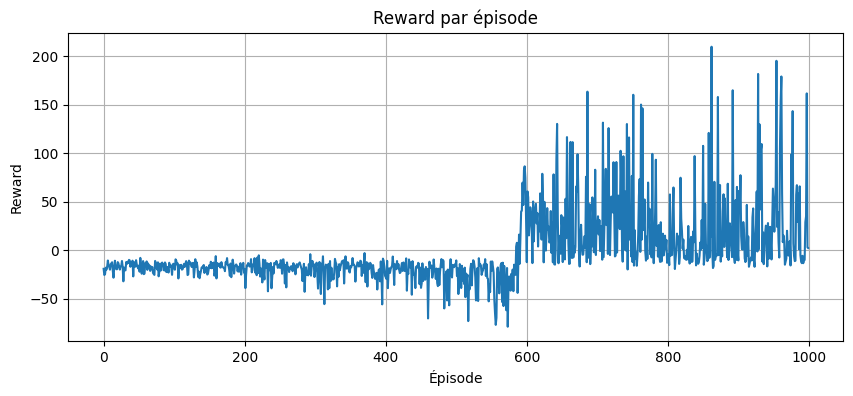

In [23]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(logs_double["episode_rewards"])
plt.title("Reward par épisode")
plt.xlabel("Épisode")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

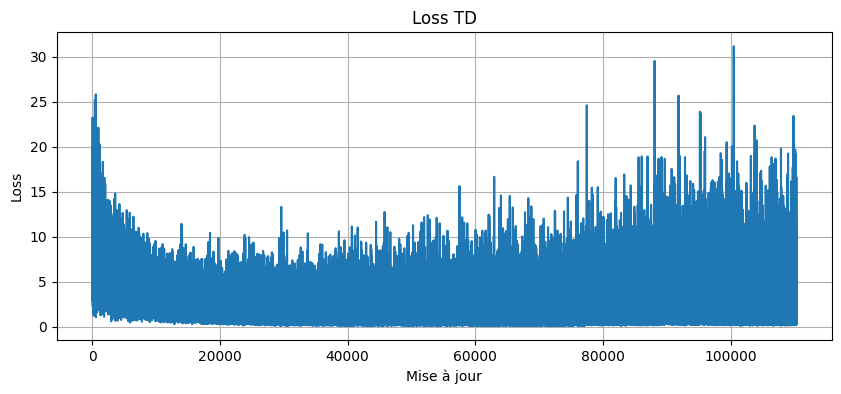

In [25]:
plt.figure(figsize=(10, 4))
plt.plot(logs_double["losses"])
plt.title("Loss TD")
plt.xlabel("Mise à jour")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [3]:
from agents import DQNAgent, DoubleDQNAgent, DuelingDQNAgent, DuelingDoubleDQNAgent
from env_utils import make_env
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

env = make_env()

obs_shape = env.observation_space.shape
n_actions = env.action_space.n

c:\Users\antho\AppData\Local\Programs\Python\Python312\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [12]:
agent_dqn = DQNAgent(obs_shape, n_actions, device)
agent_dqn.load("results/dqnV6_model_smooth_fast.pt")

agent_double = DoubleDQNAgent(obs_shape, n_actions, device)
agent_double.load("results/double_dqn_modelV1.pt")

agent_dueling = DuelingDQNAgent(obs_shape, n_actions, device)
agent_dueling.load("results/dueling_dqn_model.pt")

agent_dueling_double = DuelingDoubleDQNAgent(obs_shape, n_actions, device)
agent_dueling_double.load("results/dueling_double_dqn_model.pt")

In [13]:
from evaluate import evaluate_agent
import pandas as pd

agents = {
    "DQN": agent_dqn,
    "Double DQN": agent_double,
    "Dueling DQN": agent_dueling,
    "Dueling Double DQN": agent_dueling_double,
}

dfs = []

for name, agent in agents.items():
    df = evaluate_agent(make_env, agent, name, n_episodes=20)
    dfs.append(df)

benchmark_df = pd.concat(dfs)

In [14]:
summary = benchmark_df.groupby("agent").agg(
    reward_mean=("reward", "mean"),
    speed_mean=("avg_speed", "mean"),
    collision_rate=("collision", "mean"),
    lane_changes=("lane_changes", "mean"),
    acc_mean=("mean_abs_acceleration", "mean"),
    jerk_mean=("mean_abs_jerk", "mean"),
    episode_length_mean=("episode_length", "mean"),
)

summary

,reward_mean,speed_mean,collision_rate,lane_changes,acc_mean,jerk_mean,episode_length_mean
agent,,,,,,,
DQN,66.177387,21.201064,0.65,48.90,0.094796,0.147529,424.90
Double DQN,50.334548,22.108137,0.85,34.20,0.201462,0.252373,303.20
Dueling DQN,37.162842,23.139930,0.90,44.80,0.459705,0.518476,163.30
Dueling Double DQN,14.869500,23.136146,1.00,20.25,0.545188,0.659587,98.15


In [17]:
summary_with_uncertainty = benchmark_df.groupby("agent").agg(
    reward_mean=("reward", "mean"),
    reward_std=("reward", "std"),
    speed_mean=("avg_speed", "mean"),
    speed_std=("avg_speed", "std"),
    collision_rate_mean=("collision", "mean"),
    collision_rate_std=("collision", "std"),
    lane_changes_mean=("lane_changes", "mean"),
    lane_changes_std=("lane_changes", "std"),
    acc_mean=("mean_abs_acceleration", "mean"),
    acc_std=("mean_abs_acceleration", "std"),
    jerk_mean=("mean_abs_jerk", "mean"),
    jerk_std=("mean_abs_jerk", "std"),
    episode_length_mean=("episode_length", "mean"),
    episode_length_std=("episode_length", "std"),
)

summary_with_uncertainty

,reward_mean,reward_std,speed_mean,speed_std,collision_rate_mean,collision_rate_std,lane_changes_mean,lane_changes_std,acc_mean,acc_std,jerk_mean,jerk_std,episode_length_mean,episode_length_std
agent,,,,,,,,,,,,,,
DQN,66.177387,41.610906,21.201064,0.290514,0.65,0.489360,48.90,19.398589,0.094796,0.032332,0.147529,0.046957,424.90,127.484530
Double DQN,50.334548,43.861600,22.108137,1.247463,0.85,0.366348,34.20,20.562101,0.201462,0.202259,0.252373,0.182750,303.20,194.319758
Dueling DQN,37.162842,85.457894,23.139930,1.325512,0.90,0.307794,44.80,42.450714,0.459705,0.783365,0.518476,0.772677,163.30,181.010061
Dueling Double DQN,14.869500,28.985870,23.136146,1.243819,1.00,0.000000,20.25,17.888176,0.545188,0.939104,0.659587,0.978661,98.15,90.907863


In [16]:
import pandas as pd

summary_fmt = pd.DataFrame(index=summary_with_uncertainty.index)

summary_fmt["reward"] = summary_with_uncertainty.apply(
    lambda x: f"{x['reward_mean']:.2f} ± {x['reward_std']:.2f}", axis=1
)

summary_fmt["avg_speed"] = summary_with_uncertainty.apply(
    lambda x: f"{x['speed_mean']:.2f} ± {x['speed_std']:.2f}", axis=1
)

summary_fmt["collision_rate"] = summary_with_uncertainty.apply(
    lambda x: f"{x['collision_rate_mean']:.2f} ± {x['collision_rate_std']:.2f}", axis=1
)

summary_fmt["lane_changes"] = summary_with_uncertainty.apply(
    lambda x: f"{x['lane_changes_mean']:.2f} ± {x['lane_changes_std']:.2f}", axis=1
)

summary_fmt["acc_mean"] = summary_with_uncertainty.apply(
    lambda x: f"{x['acc_mean']:.3f} ± {x['acc_std']:.3f}", axis=1
)

summary_fmt["jerk_mean"] = summary_with_uncertainty.apply(
    lambda x: f"{x['jerk_mean']:.3f} ± {x['jerk_std']:.3f}", axis=1
)

summary_fmt["episode_length"] = summary_with_uncertainty.apply(
    lambda x: f"{x['episode_length_mean']:.2f} ± {x['episode_length_std']:.2f}", axis=1
)

summary_fmt

NameError: name 'summary_with_uncertainty' is not defined

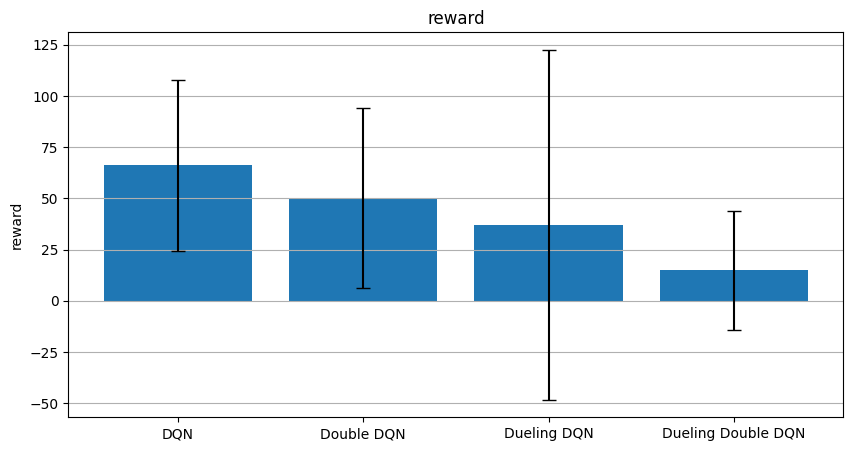

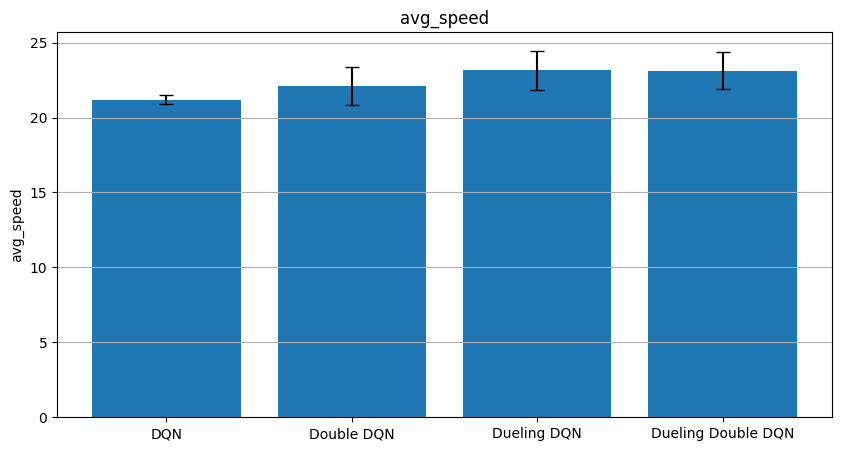

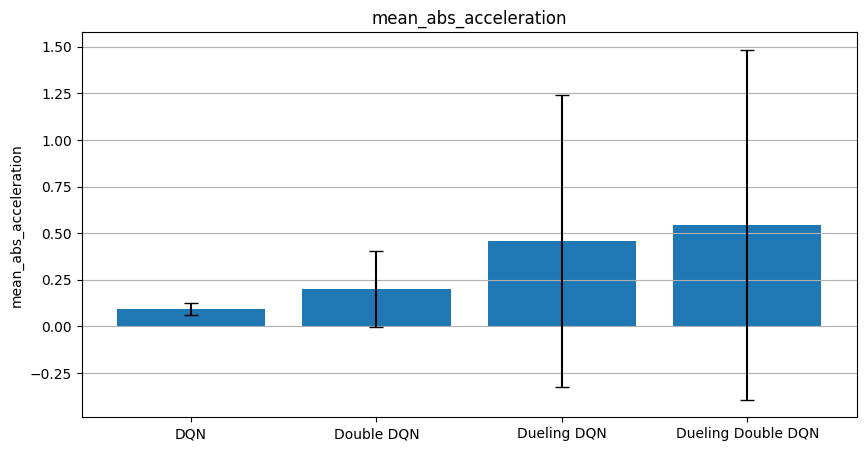

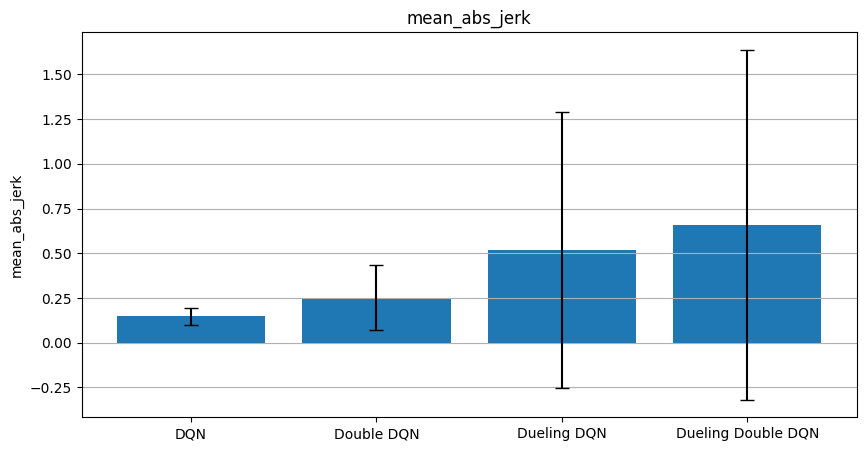

In [15]:
from plots import plot_eval_metric_bar
plot_eval_metric_bar(benchmark_df, "reward")
plot_eval_metric_bar(benchmark_df, "avg_speed")
plot_eval_metric_bar(benchmark_df, "mean_abs_acceleration")
plot_eval_metric_bar(benchmark_df, "mean_abs_jerk")